# Check Parameter Embeddings

In [76]:
# Add ../ as a directory to import from
import sys
sys.path.append('../')

# Load Model
from models.plightning import MainModule
model = MainModule.load_from_checkpoint("../log/20250312_Final_for_Paper_Topview_RGBOnly_FixViT_NoPosEmbonParams/version_1/checkpoints/best_epoch=07.ckpt")
model.eval()

MainModule(
  (image_encoder): ViT_FeatureExtractor(
    (model): Dinov2Model(
      (embeddings): Dinov2Embeddings(
        (patch_embeddings): Dinov2PatchEmbeddings(
          (projection): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (encoder): Dinov2Encoder(
        (layer): ModuleList(
          (0-11): 12 x Dinov2Layer(
            (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
            (attention): Dinov2Attention(
              (attention): Dinov2SelfAttention(
                (query): Linear(in_features=384, out_features=384, bias=True)
                (key): Linear(in_features=384, out_features=384, bias=True)
                (value): Linear(in_features=384, out_features=384, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
              (output): Dinov2SelfOutput(
                (dense): Linear(in_features=384, out_features=384, bias=True)


In [77]:
import os
import numpy as np
from tqdm import tqdm
from string_to_xml_to_vec import xml2vec, linked_to_recursive
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

def process_xml_files(dataset_dir, file_suffix):
    xml_files = [f for f in os.listdir(dataset_dir) if f.endswith(file_suffix)]
    xml_files.sort()
    plant_array = []
    for xml_file in tqdm(xml_files):
        xml_file = os.path.join(dataset_dir, xml_file)
        tree = ET.parse(xml_file)
        root = tree.getroot()
        root = linked_to_recursive(root)
        for plant_instance in root:
            plant_instance_array = []
            xml2vec(plant_instance, plant_instance_array)
            plant_array.append(plant_instance_array)
    return plant_array

def process_xmls(xml_files):
    plant_array = []
    for xml_file in tqdm(xml_files):
        tree = ET.parse(xml_file)
        root = tree.getroot()
        root = linked_to_recursive(root)
        for plant_instance in root:
            plant_instance_array = []
            xml2vec(plant_instance, plant_instance_array)
            plant_array.append(plant_instance_array)
    return plant_array

def extract_params(plant_array):
    all_shoot_params = []
    all_internode_params = []
    all_petiole_params = []
    all_leaf_params = []
    for token in plant_array:
        for vec in token:
            organ_type = vec[1]
            if organ_type == 0:
                all_shoot_params.append(vec[2:])
            elif organ_type == 1:
                all_internode_params.append(vec[2:])
            elif organ_type == 2:
                all_petiole_params.append(vec[2:])
            elif organ_type == 3:
                all_leaf_params.append(vec[2:])
    return (np.array(all_shoot_params), np.array(all_internode_params), np.array(all_petiole_params), np.array(all_leaf_params))

In [78]:
# Load XML File
# GT 데이터셋 처리
gt_dataset_dir = "../data/2000_Plots_20241210/xml"
xml_files = [os.path.join(gt_dataset_dir, f) for f in os.listdir(gt_dataset_dir) if f.endswith(".xml")]
# Process first 1000 files
xml_files = xml_files[:1000]
gt_plant_array = process_xmls(xml_files)
gt_shoot_params, gt_internode_params, gt_petiole_params, gt_leaf_params = extract_params(gt_plant_array)

100%|██████████| 1000/1000 [00:08<00:00, 113.35it/s]


In [79]:
from tqdm.auto import tqdm
import torch
from plant_tokenizer import vec2token

# Get Param embeddings
param_embeddings = []
scaler = model.sequence_decoder.scaler
param_embedding_model = model.sequence_decoder.param_embedding
total_tokens = []
for plant_array in tqdm(gt_plant_array):
    plant_tokens = vec2token(plant_array)
    total_tokens.append(plant_tokens)
    params = plant_tokens[:,1:]
    with torch.no_grad():
        scaled_params = scaler.transform(params)
        scaled_params = scaled_params.to(model.device)
        param_embedding = param_embedding_model(scaled_params)

    param_embeddings.append(param_embedding.cpu().numpy())


  0%|          | 0/1000 [00:00<?, ?it/s]

In [80]:
total_emb_array = np.concatenate(param_embeddings, axis=1).squeeze(0)
total_tokens = np.concatenate(total_tokens, axis=0)

In [81]:
total_tokens.shape

(151561, 19)

In [87]:
print(total_emb_array.shape)

# Use first ramdom 1000 samples

# Randomly sample 1000 samples from total_emb_array
num_samples = 1000
random_indices = np.random.choice(total_emb_array.shape[0], num_samples, replace=False)
sampled_emb_array = total_emb_array[random_indices]
sampled_tokens_array = total_tokens[random_indices]
print(sampled_emb_array.shape)


(151561, 384)
(1000, 384)


In [83]:
# Visualize vectors
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import umap

In [84]:
if 0:
    if 1:
        from openTSNE import TSNE # pip install openTSNE pynndescent
        # Assuming total_emb_array is already defined
        tsne = TSNE(n_components=2, random_state=42, n_jobs=-1, perplexity=30, metric="cosine", initialization="pca")
        embeddings_2d_tsne = tsne.fit(sampled_emb_array)  
    else:
        #from openTSNE import TSNE
        from sklearn.manifold import TSNE
        tsne = TSNE(n_components=2, random_state=42)
        embeddings_2d_tsne = tsne.fit_transform(sampled_emb_array)

In [88]:
# Using UMAP for faster dimensionality reduction
reducer = umap.UMAP(n_components=2, random_state=42, metric="cosine")
embeddings_2d_umap = reducer.fit_transform(sampled_emb_array)

/home/lion397/codes/Image2PlantArchitecture/.env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/lion397/codes/Image2PlantArchitecture/.env/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/lion397/codes/Image2PlantArchitecture/.env/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/lion397/codes/Image2PlantArchitecture/.env/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/lion397/codes/Image2PlantArchitecture/.env/lib/python3.8/site-packa

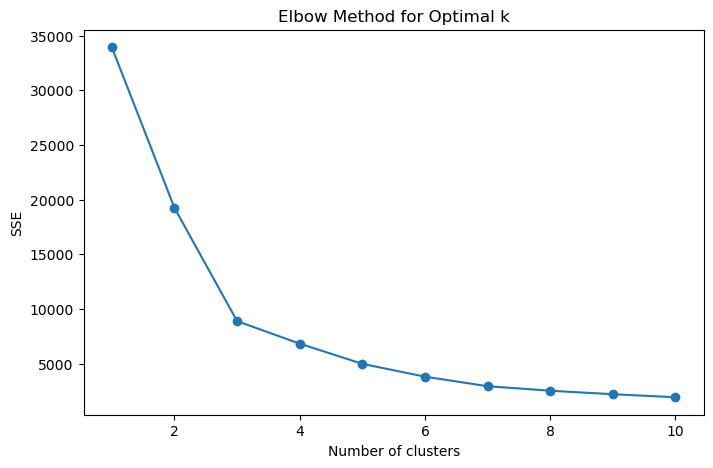

In [89]:
# Assuming sampled_emb_array is already defined
sse = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(sampled_emb_array)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.title('Elbow Method for Optimal k')
plt.show()

/home/lion397/codes/Image2PlantArchitecture/.env/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/lion397/codes/Image2PlantArchitecture/.env/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/lion397/codes/Image2PlantArchitecture/.env/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/lion397/codes/Image2PlantArchitecture/.env/lib/python3.8/site-packa

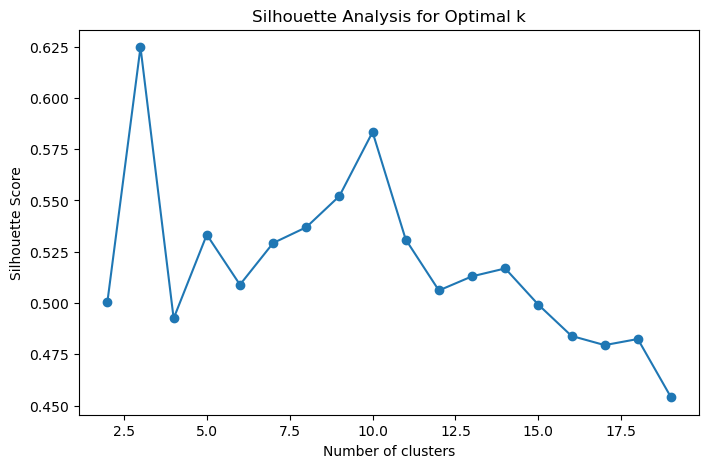

In [90]:
from sklearn.metrics import silhouette_score

# Assuming sampled_emb_array is already defined
silhouette_scores = []
k_range = range(2, 20)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(sampled_emb_array)
    score = silhouette_score(sampled_emb_array, clusters)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis for Optimal k')
plt.show()

/home/lion397/codes/Image2PlantArchitecture/.env/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


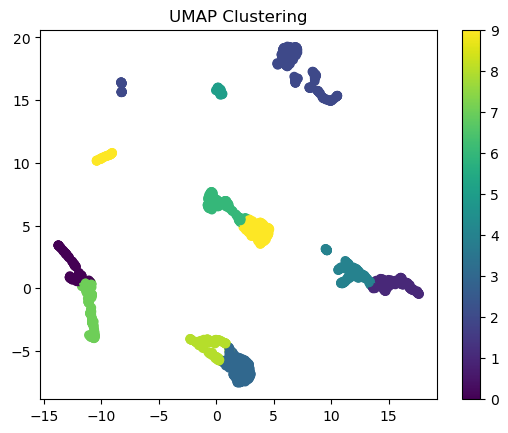

In [91]:
#n_clusters = k_range[np.argmax(silhouette_scores)]
n_clusters = 10

# Clustering using K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42)  # Adjust the number of clusters as needed
clusters = kmeans.fit_predict(sampled_emb_array)
# Visualization using UMAP
# plt.subplot(1, 2, 2)
plt.scatter(embeddings_2d_umap[:, 0], embeddings_2d_umap[:, 1], c=clusters, cmap='viridis')
plt.title('UMAP Clustering')
plt.colorbar()

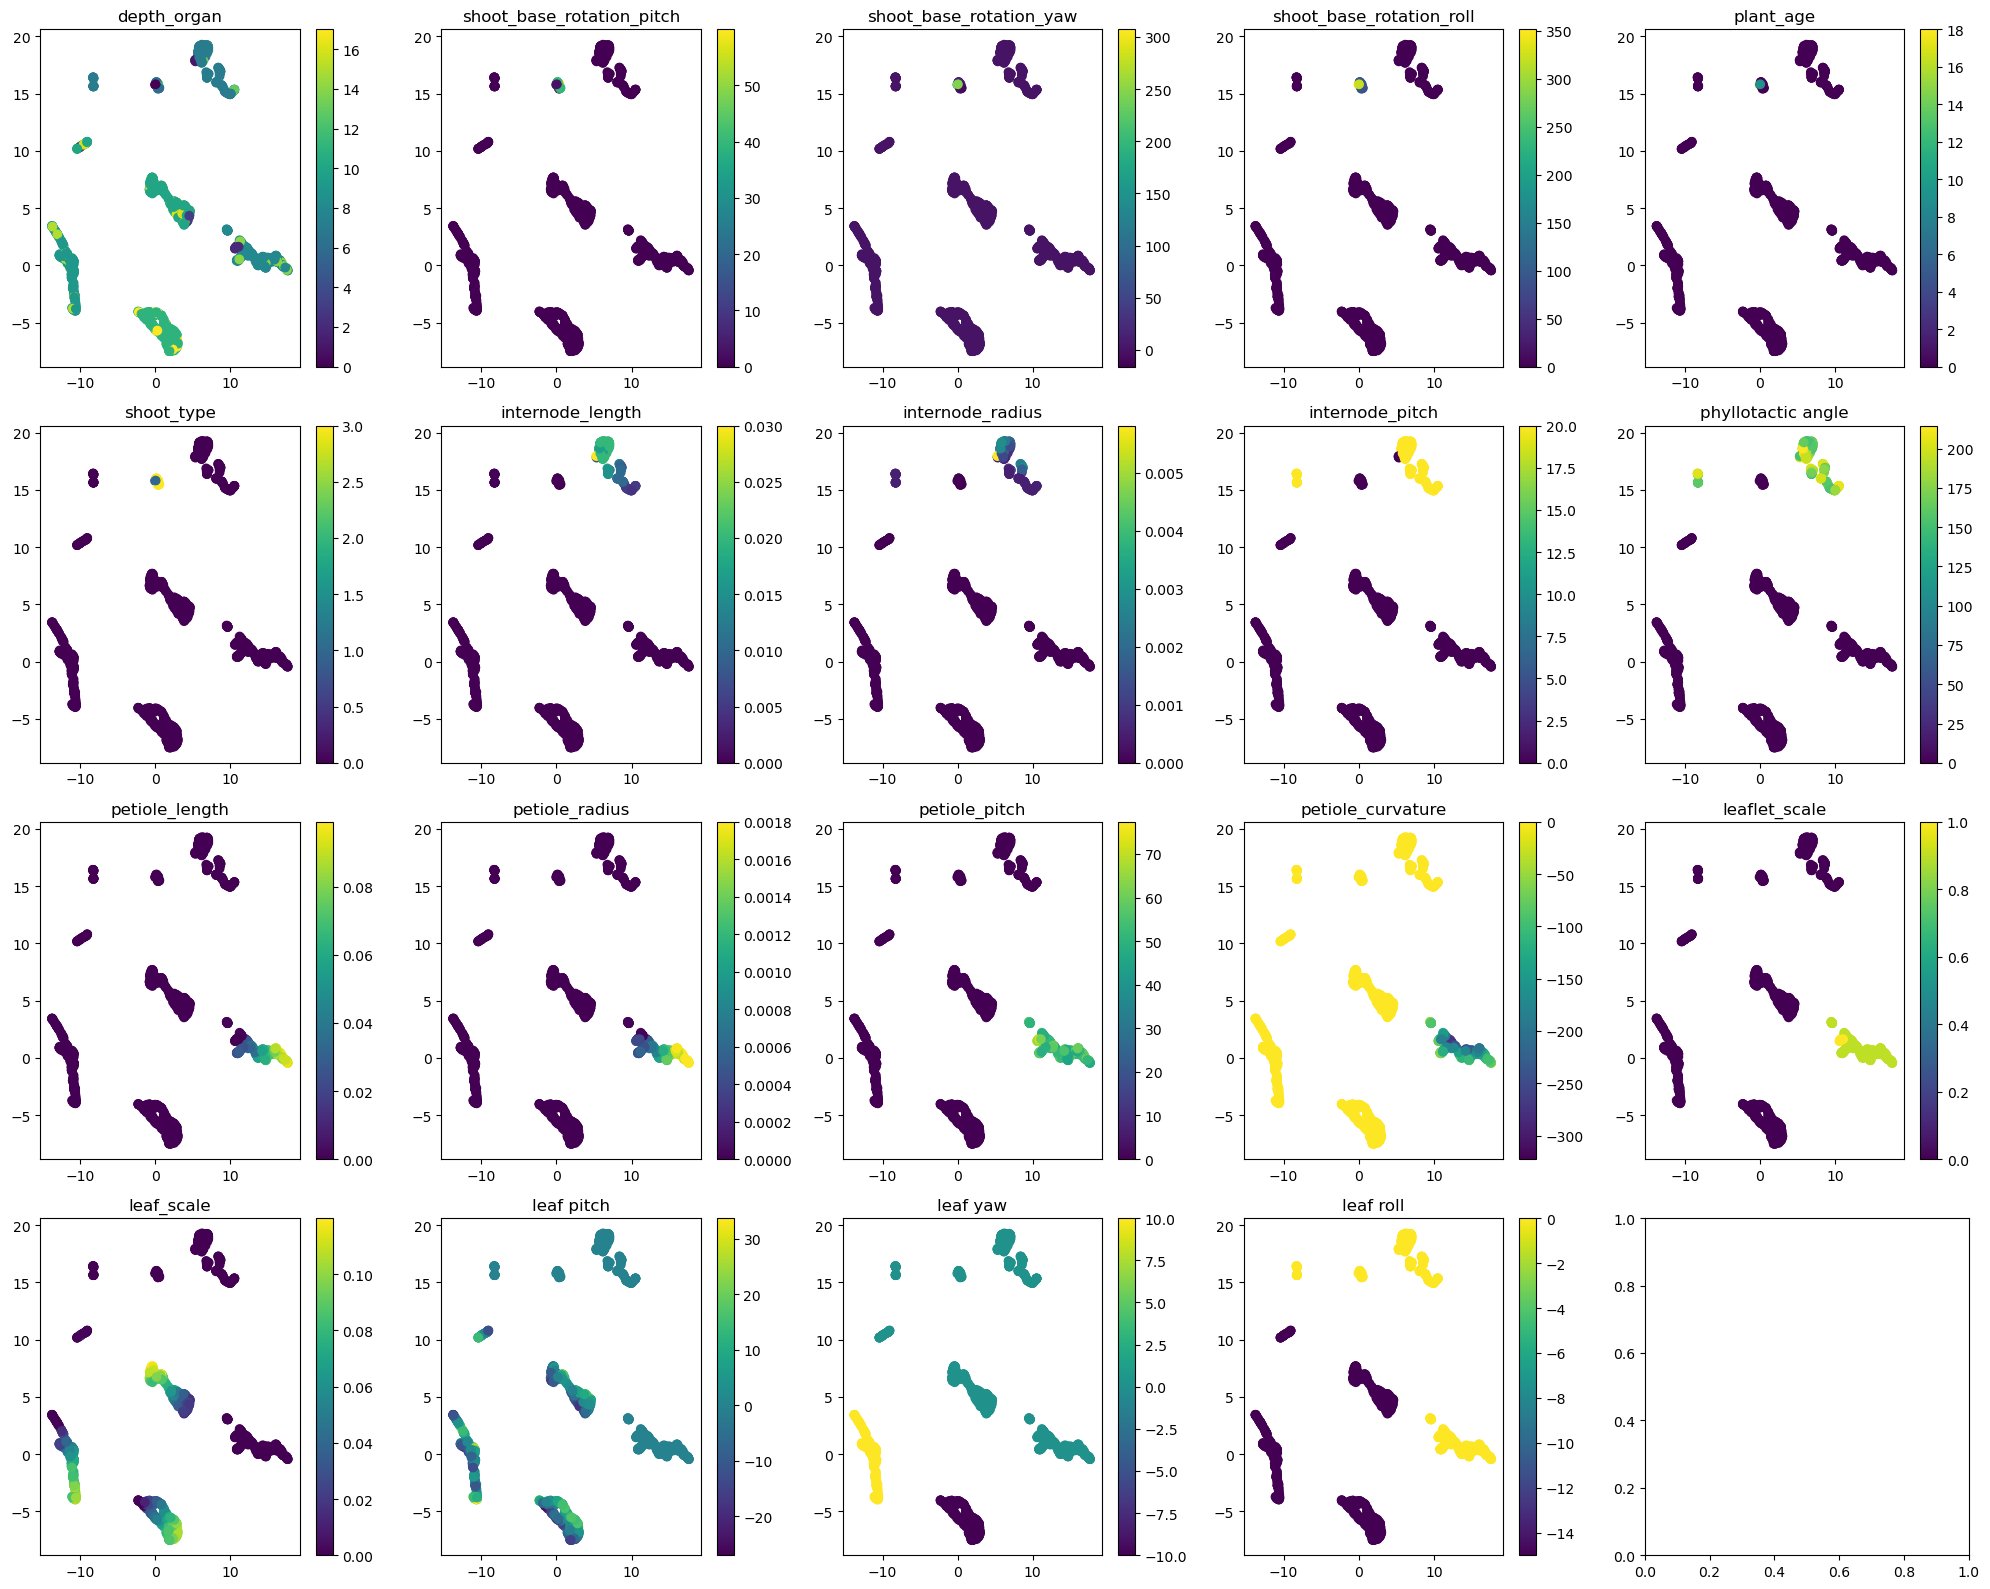

In [92]:
# Visualization using UMAP with 4x5 Subplot Grid
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

param_names = [
    "depth_organ",  # token[0]
    "shoot_base_rotation_pitch",  # token[1]
    "shoot_base_rotation_yaw",    # token[2]
    "shoot_base_rotation_roll",   # token[3]
    "plant_age",                  # token[4]
    "shoot_type",                 # token[5]
    "internode_length",           # token[6]
    "internode_radius",           # token[7]
    "internode_pitch",            # token[8]
    "phyllotactic angle",         # token[9]
    "petiole_length",             # token[10]
    "petiole_radius",             # token[11]
    "petiole_pitch",              # token[12]
    "petiole_curvature",          # token[13]
    "leaflet_scale",              # token[14]
    "leaf_scale",                 # token[15]
    "leaf pitch",                 # token[16]
    "leaf yaw",                   # token[17]
    "leaf roll"                   # token[18]
]

for i in range(19):
    ax = axes[i]
    scatter = ax.scatter(embeddings_2d_umap[:, 0], embeddings_2d_umap[:, 1], c=sampled_tokens_array[:, i], cmap='viridis')
    ax.set_title(f'{param_names[i]}')
    fig.colorbar(scatter, ax=ax)

plt.tight_layout()
plt.show()

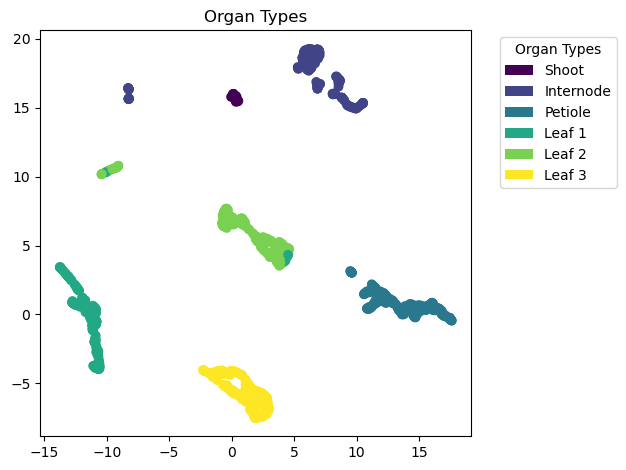

In [99]:
from plant_tokenizer import SOS_token, EOS_token, PAD_token
from matplotlib.patches import Patch

depth = sampled_tokens_array[:,0] // 6
organ = sampled_tokens_array[:,0] % 6

# Define labels for organ types
organ_labels = {
    0: 'Shoot',
    1: 'Internode',
    2: 'Petiole',
    3: 'Leaf 1',
    4: 'Leaf 2',
    5: 'Leaf 3',
}

# Create scatter plot
scatter = plt.scatter(embeddings_2d_umap[:, 0], embeddings_2d_umap[:, 1], c=organ, cmap='viridis')
plt.title('Organ Types')

# Create legend
legend_elements = [Patch(facecolor=plt.cm.viridis(i / 5), label=label) for i, label in organ_labels.items()]
plt.legend(handles=legend_elements, title="Organ Types", bbox_to_anchor=(1.05, 1), loc='upper left')

# Show plot
plt.tight_layout()
plt.show()

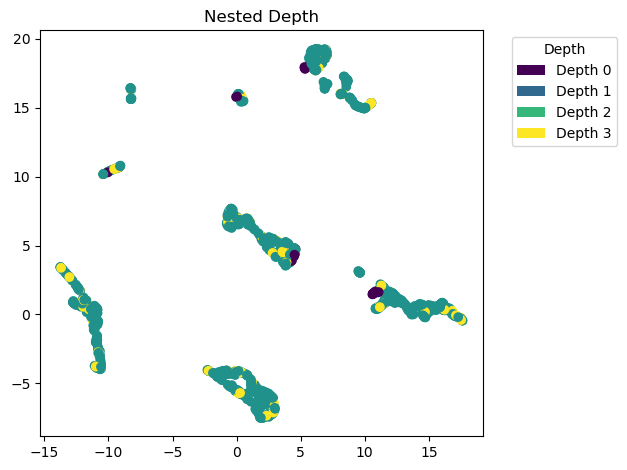

In [94]:
from plant_tokenizer import SOS_token, EOS_token, PAD_token
from matplotlib.patches import Patch

depth = sampled_tokens_array[:,0] // 6
organ = sampled_tokens_array[:,0] % 6

# Define labels for organ types
depth_labels = {
    0: 'Depth 0',
    1: 'Depth 1',
    2: 'Depth 2',
    3: 'Depth 3',
}

# Create scatter plot
scatter = plt.scatter(embeddings_2d_umap[:, 0], embeddings_2d_umap[:, 1], c=depth, cmap='viridis')
plt.title('Nested Depth')

# Create legend
legend_elements = [Patch(facecolor=plt.cm.viridis(i / 3), label=label) for i, label in depth_labels.items()]
plt.legend(handles=legend_elements, title="Depth", bbox_to_anchor=(1.05, 1), loc='upper left')

# Show plot
plt.tight_layout()
plt.show()

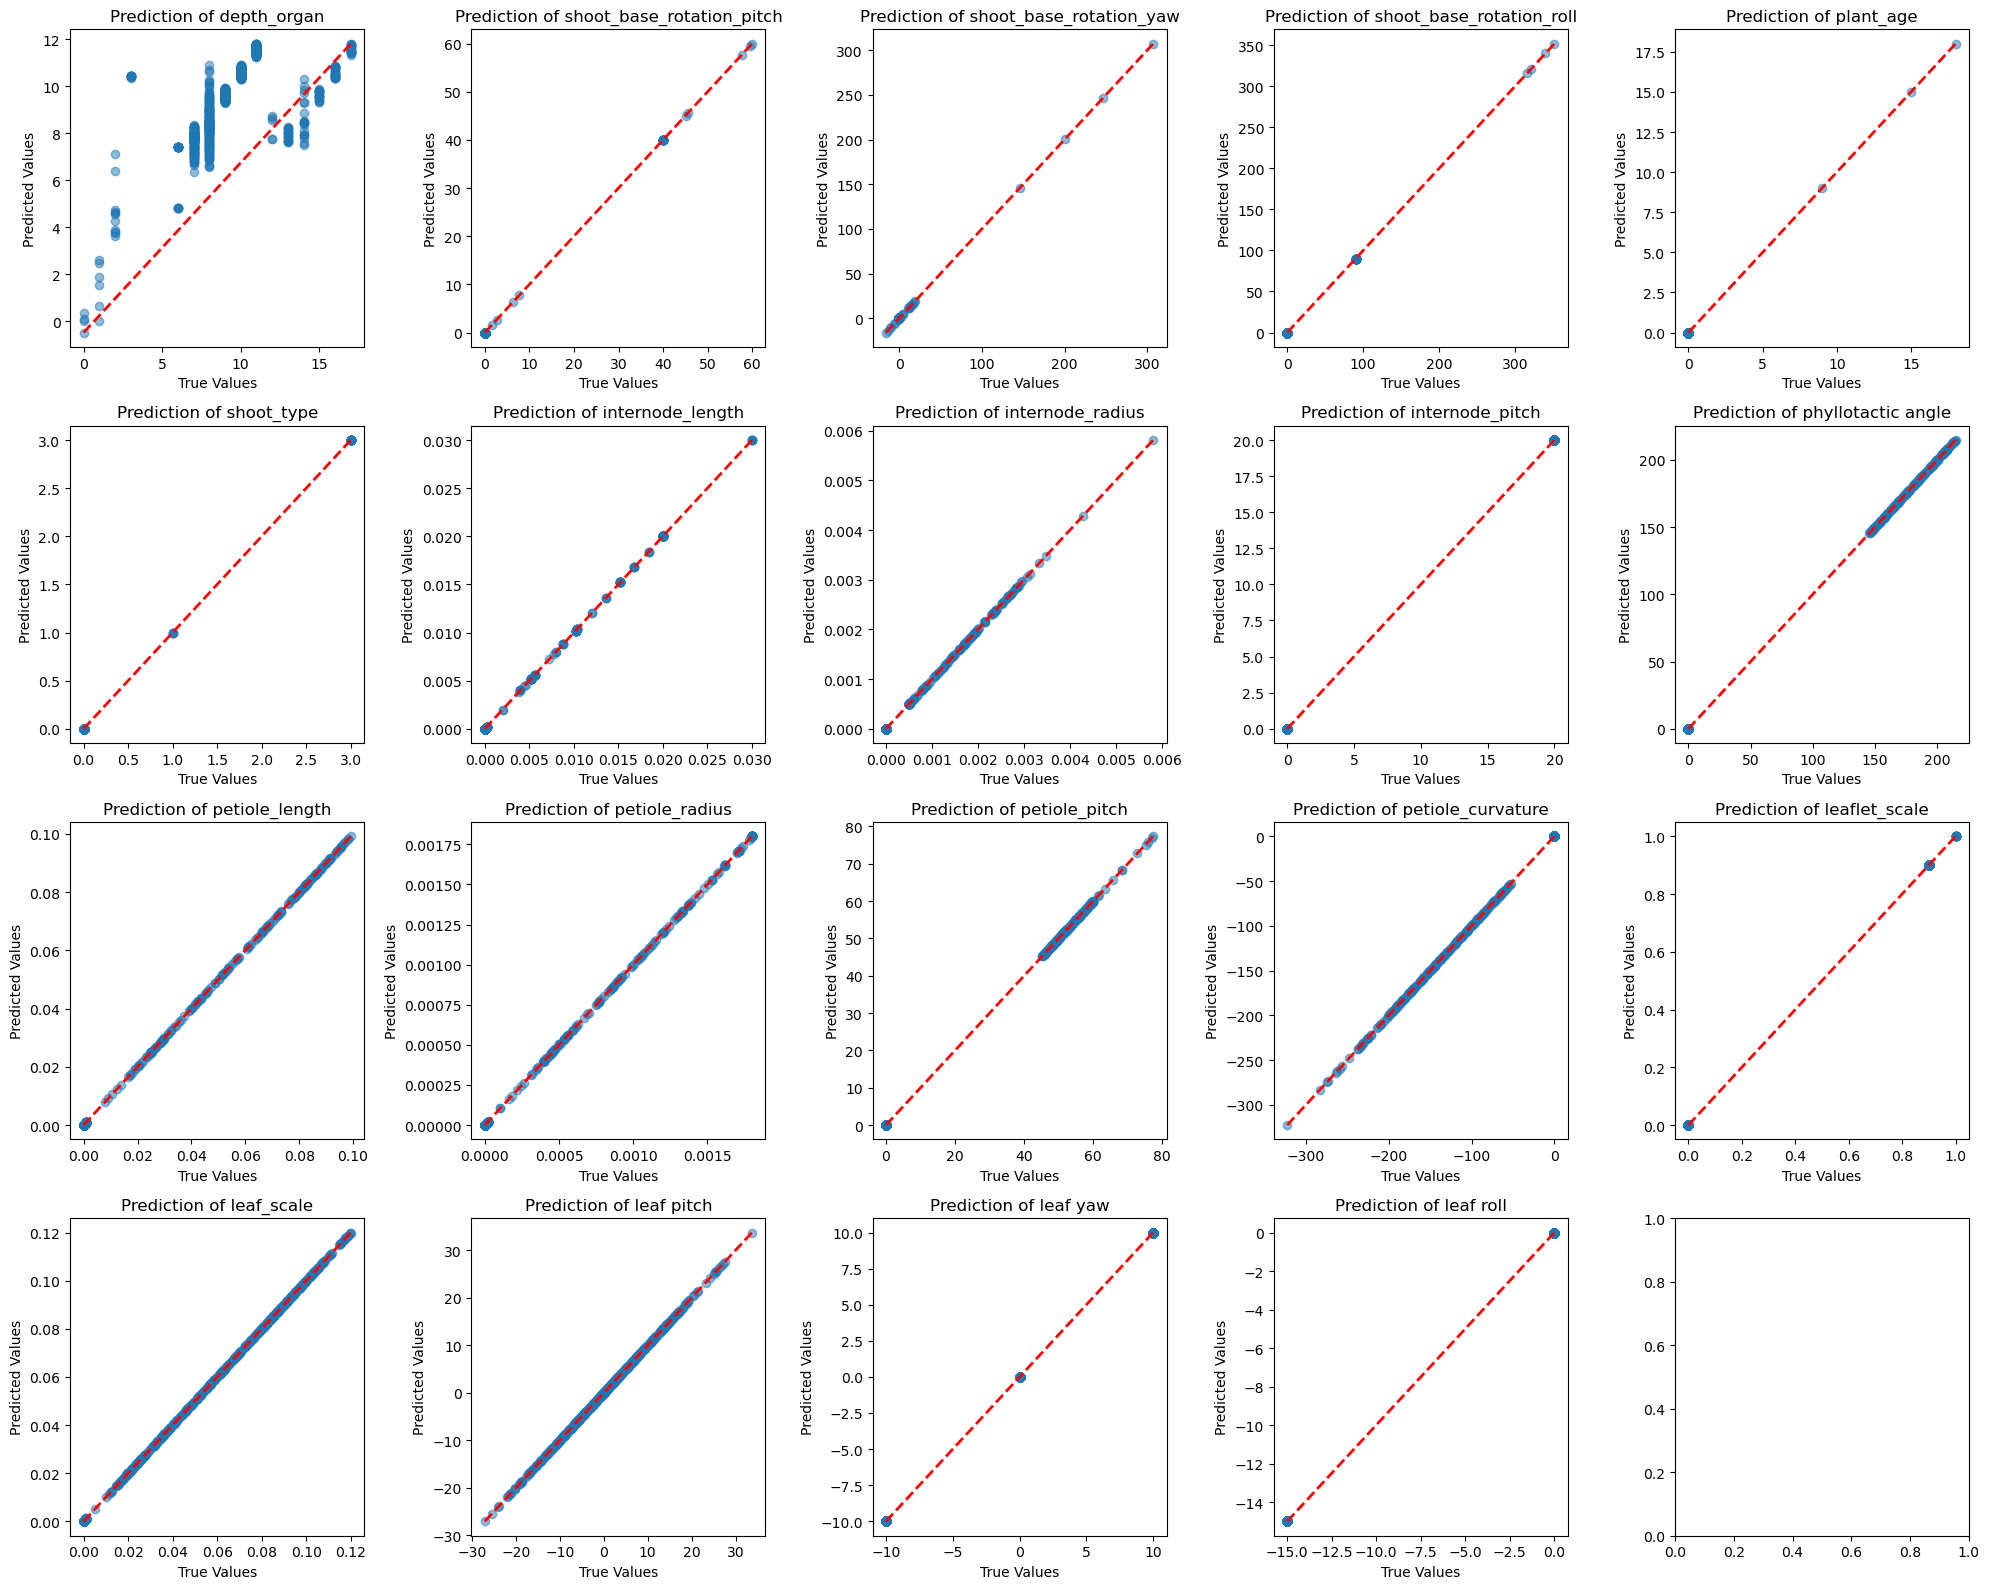

In [100]:
# Recover Paramters from paramter embedding?
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Assuming sampled_emb_array and sampled_tokens_array are already defined
num_features = 19  # Number of features to predict (0 to 18)

# Create a 4x5 subplot grid
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for i in range(num_features):
    # Train a linear regression model
    regression_model = LinearRegression()
    x = sampled_emb_array
    y = sampled_tokens_array[:, i].reshape(-1,1)

    regression_model.fit(x, y) # sampled_tokens_array[0] is depth_organ
    
    # Predict the values
    predictions = regression_model.predict(x)
    
    # Plot the true vs predicted values
    ax = axes[i]
    ax.scatter(y, predictions, alpha=0.5)
    ax.plot([y.min(), y.max()],
            [predictions.min(), predictions.max()],
            'r--', lw=2)
    ax.set_title(f'Prediction of {param_names[i]}')
    ax.set_xlabel('True Values')
    ax.set_ylabel('Predicted Values')

plt.tight_layout()
plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

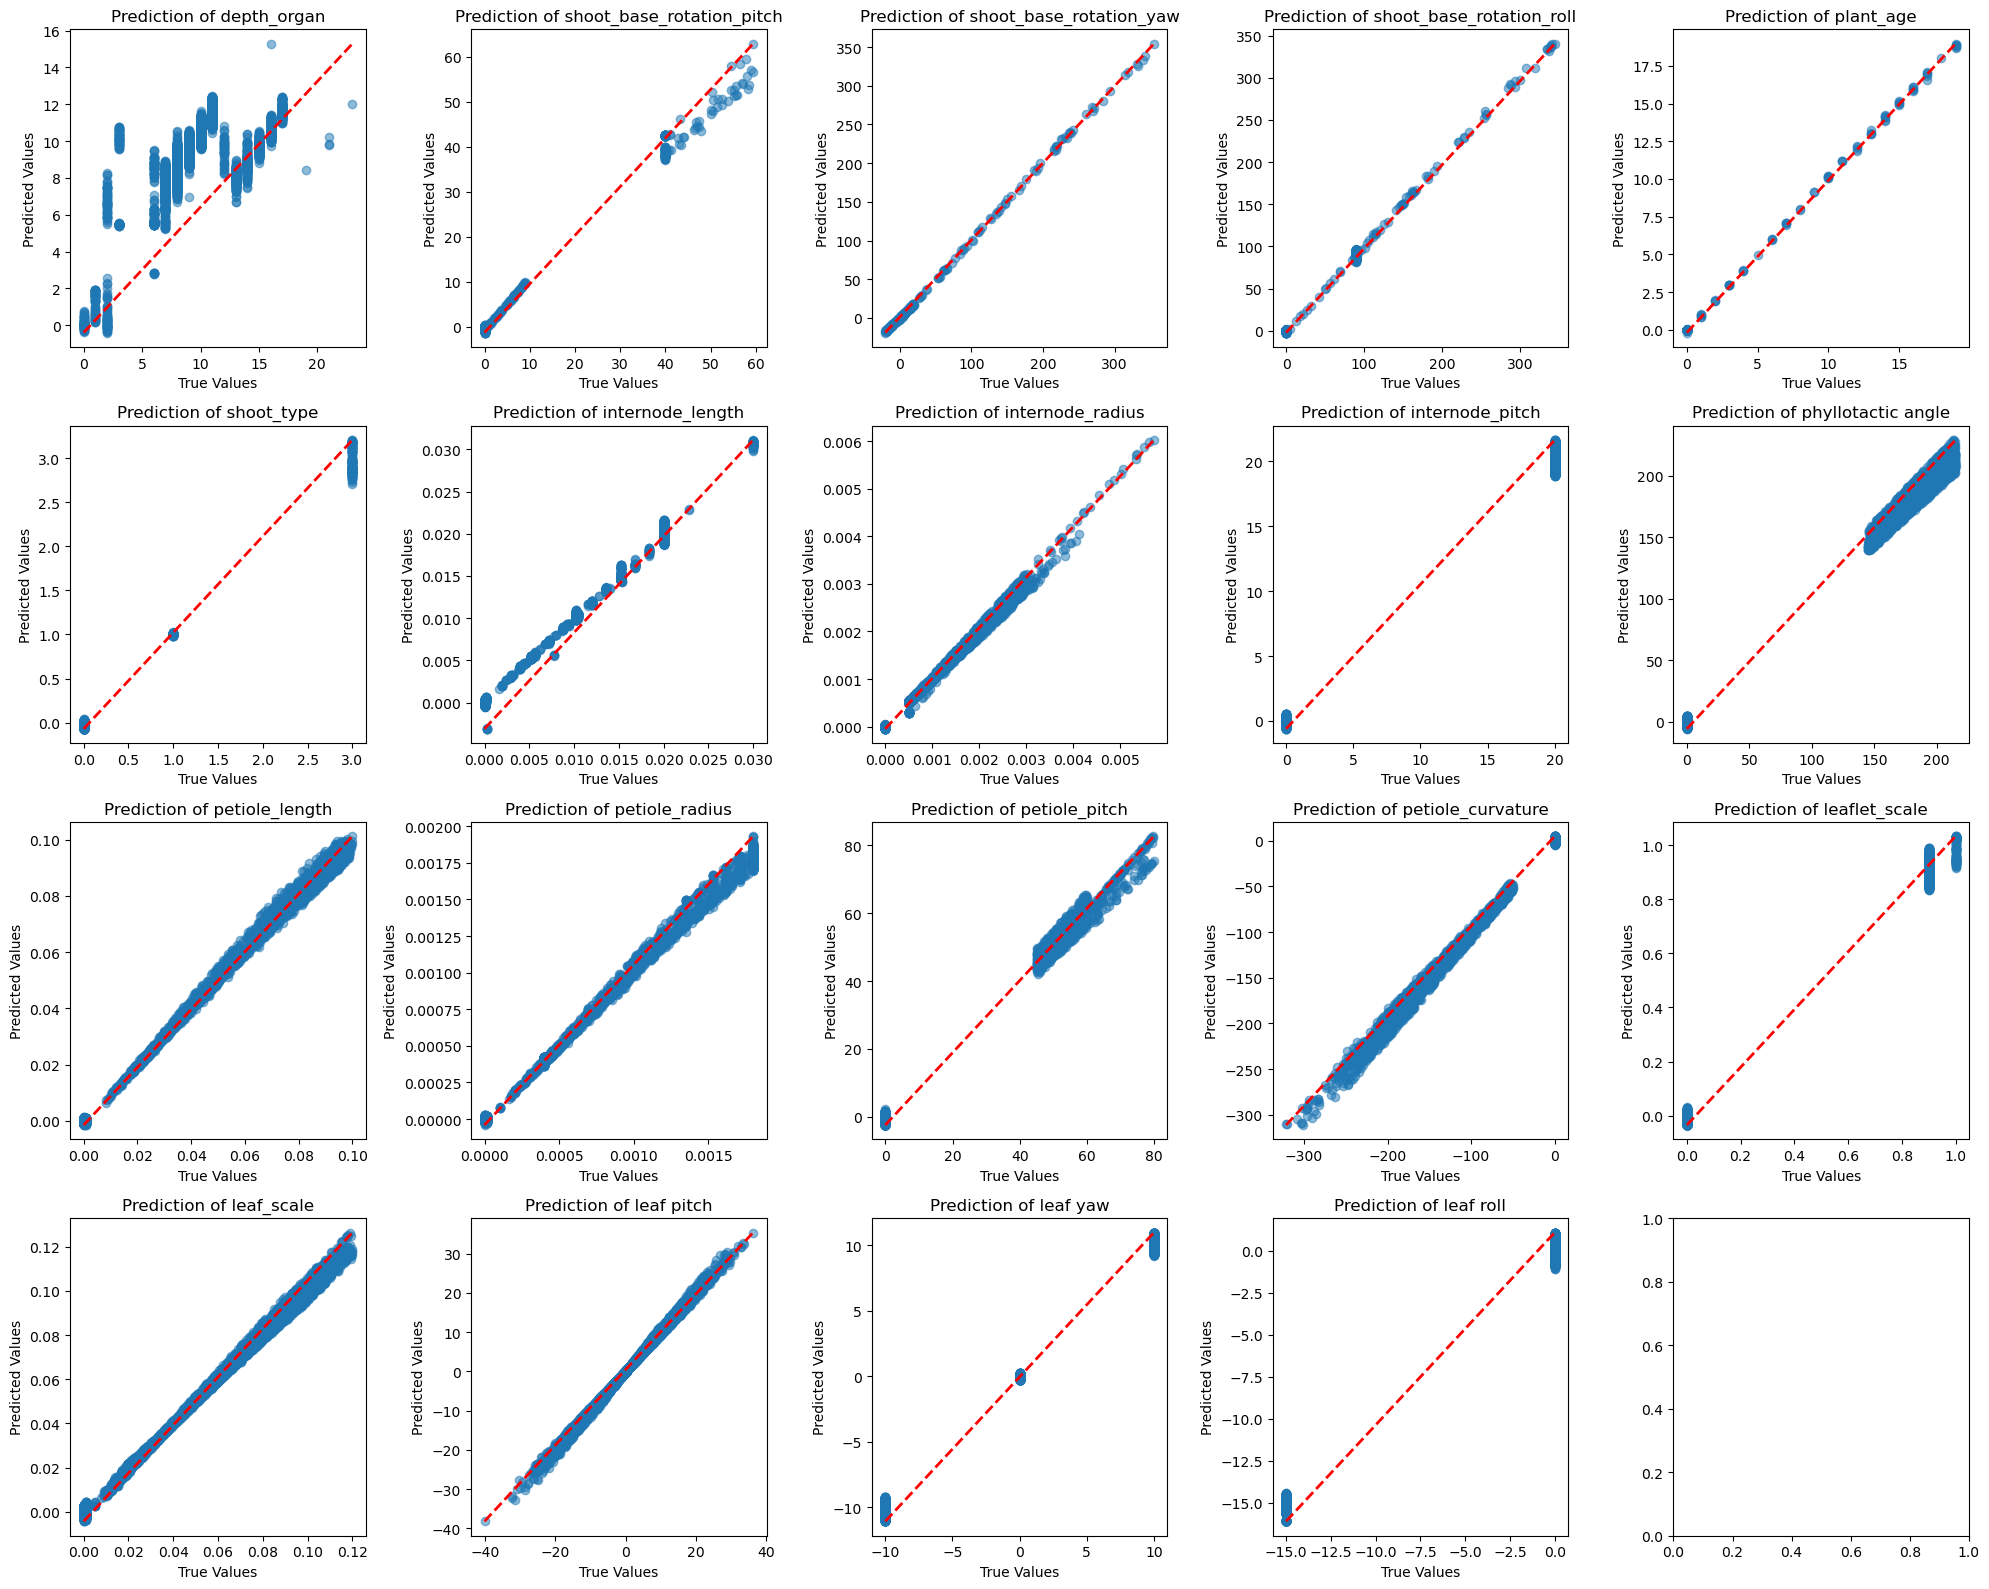

In [71]:
# What if positonal embeeding is added?
# Get Param embeddings
param_embeddings = []
scaler = model.sequence_decoder.scaler
param_embedding_model = model.sequence_decoder.param_embedding
pos_embedding = model.sequence_decoder.depth_organ_positional_encoding
total_tokens = []
for plant_array in tqdm(gt_plant_array):
    plant_tokens = vec2token(plant_array)
    total_tokens.append(plant_tokens)
    params = plant_tokens[:,1:]
    with torch.no_grad():
        scaled_params = scaler.transform(params)
        scaled_params = scaled_params.to(model.device)
        param_embedding = param_embedding_model(scaled_params)
        param_embedding = param_embedding.permute(1,0,2)
        param_embedding = pos_embedding(param_embedding)
        param_embedding = param_embedding.permute(1,0,2)
    param_embeddings.append(param_embedding.cpu().numpy())

total_emb_array = np.concatenate(param_embeddings, axis=1).squeeze(0)
total_tokens = np.concatenate(total_tokens, axis=0)


# Randomly sample 1000 samples from total_emb_array
num_samples = 10000
random_indices = np.random.choice(total_emb_array.shape[0], num_samples, replace=False)
sampled_emb_array = total_emb_array[random_indices]
sampled_tokens_array = total_tokens[random_indices]


# Recover Paramters from paramter embedding?
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Assuming sampled_emb_array and sampled_tokens_array are already defined
num_features = 19  # Number of features to predict (0 to 18)

# Create a 4x5 subplot grid
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for i in range(num_features):
    # Train a linear regression model
    regression_model = LinearRegression()
    x = sampled_emb_array
    y = sampled_tokens_array[:, i].reshape(-1,1)

    regression_model.fit(x, y) # sampled_tokens_array[0] is depth_organ
    
    # Predict the values
    predictions = regression_model.predict(x)
    
    # Plot the true vs predicted values
    ax = axes[i]
    ax.scatter(y, predictions, alpha=0.5)
    ax.plot([y.min(), y.max()],
            [predictions.min(), predictions.max()],
            'r--', lw=2)
    ax.set_title(f'Prediction of {param_names[i]}')
    ax.set_xlabel('True Values')
    ax.set_ylabel('Predicted Values')

plt.tight_layout()
plt.show()

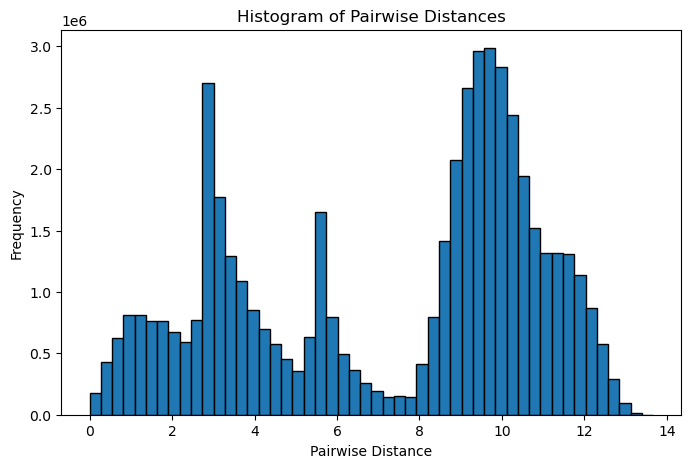

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

# Assuming sampled_emb_array is already defined
# Calculate pairwise distances
pairwise_distances = pdist(sampled_emb_array, metric='euclidean')

# Plot histogram of pairwise distances
plt.figure(figsize=(8, 5))
plt.hist(pairwise_distances, bins=50, edgecolor='k')
plt.xlabel('Pairwise Distance')
plt.ylabel('Frequency')
plt.title('Histogram of Pairwise Distances')
plt.show()

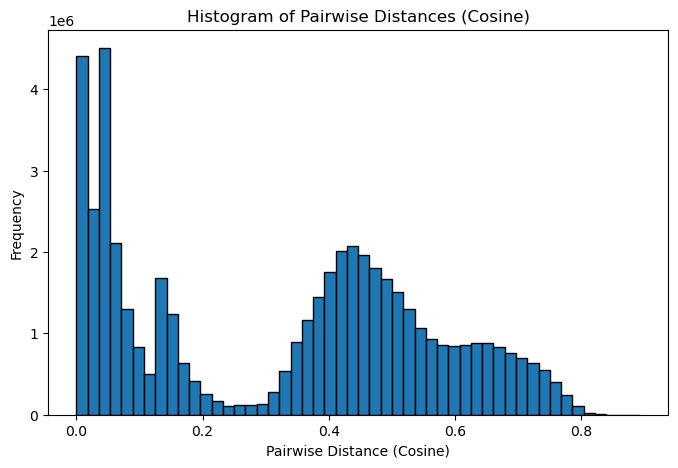

In [66]:
# Calculate pairwise distances using cosine metric
pairwise_distances = pdist(sampled_emb_array, metric='cosine')

# Plot histogram of pairwise distances
plt.figure(figsize=(8, 5))
plt.hist(pairwise_distances, bins=50, edgecolor='k')
plt.xlabel('Pairwise Distance (Cosine)')
plt.ylabel('Frequency')
plt.title('Histogram of Pairwise Distances (Cosine)')
plt.show()